In [ ]:
!pip install tensorflow pandas scikit-learn matplotlib

In [1]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Cargar datos
df = pd.read_csv('df_total.csv', encoding='UTF-8')

print("Datos cargados:")
print(f"Total: {len(df)} noticias")
print(f"Categorías: {df['Type'].unique()}")

# Convertir etiquetas de texto a números
le = LabelEncoder()
df['label_num'] = le.fit_transform(df['Type'])
num_clases = len(le.classes_)

print(f"\nEtiquetas convertidas:")
for i, clase in enumerate(le.classes_):
    print(f"   {clase}: {i}")

I0000 00:00:1774365394.541919   11172 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774365397.165937   11172 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774365401.278846   11172 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Datos cargados:
Total: 1217 noticias
Categorías: ['Otra' 'Regulaciones' 'Alianzas' 'Macroeconomia' 'Innovacion'
 'Sostenibilidad' 'Reputacion']

Etiquetas convertidas:
   Alianzas: 0
   Innovacion: 1
   Macroeconomia: 2
   Otra: 3
   Regulaciones: 4
   Reputacion: 5
   Sostenibilidad: 6


In [2]:
# Parámetros de configuración
vocab_size = 10000     # Vocabulario de 10,000 palabras más comunes
max_length = 200       # Longitud máxima de cada noticia
trunc_type = 'post'    # Cortar al final si es muy larga
padding_type = 'post'  # Rellenar al final si es muy corta

# Crear tokenizer
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(df['news'])

# Convertir texto a secuencias de números
sequences = tokenizer.texts_to_sequences(df['news'])

# Aplicar padding (hacer que todas tengan la misma longitud)
padded = pad_sequences(
    sequences, 
    maxlen=max_length,
    padding=padding_type, 
    truncating=trunc_type
)

print(f"Tokenización completada:")
print(f"   Vocabulario: {len(tokenizer.word_index)} palabras")
print(f"   Forma de datos: {padded.shape}")

# Ejemplo de transformación
print(f"\nEjemplo de tokenización:")
print(f"Original: {df['news'][0][:100]}...")
print(f"Secuencia: {sequences[0][:20]}...")
print(f"Padded: {padded[0][:20]}...")

Tokenización completada:
   Vocabulario: 31188 palabras
   Forma de datos: (1217, 200)

Ejemplo de tokenización:
Original: Durante el foro La banca articulador empresarial para el desarrollo sostenible el director de sosten...
Secuencia: [64, 5, 1574, 3, 208, 1, 664, 13, 5, 83, 122, 5, 197, 2, 142, 7, 45, 752, 2, 25]...
Padded: [  64    5 1574    3  208    1  664   13    5   83  122    5  197    2
  142    7   45  752    2   25]...


In [3]:
# Dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(
    padded, 
    df['label_num'], 
    test_size=0.2, 
    random_state=42,
    stratify=df['label_num']
)

print(f"Datos divididos:")
print(f"   Train: {X_train.shape}")
print(f"   Test: {X_test.shape}")

Datos divididos:
   Train: (973, 200)
   Test: (244, 200)


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout

# Crear modelo
model = Sequential([
    # 1. Embedding: Convierte palabras en vectores densos
    Embedding(vocab_size, 16, input_length=max_length),
    
    # 2. GlobalAveragePooling: Reduce dimensionalidad
    GlobalAveragePooling1D(),
    
    # 3. Capa Dense intermedia
    Dense(24, activation='relu'),
    
    # 4. Dropout para evitar overfitting
    Dropout(0.5),
    
    # 5. Capa de salida (una neurona por categoría)
    Dense(num_clases, activation='softmax')
])

# Compilar modelo
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Ver arquitectura
print(" Arquitectura del modelo:")
model.summary()

/home/ciabd12/anaconda3/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


 Arquitectura del modelo:


W0000 00:00:1774365502.523843   11172 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenar
print("\nEntrenando modelo...")

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=2
)

print("\nEntrenamiento completado")


🔄 Entrenando modelo...
Epoch 1/10
31/31 - 2s - 50ms/step - accuracy: 0.2754 - loss: 1.9234 - val_accuracy: 0.2787 - val_loss: 1.8984
Epoch 2/10
31/31 - 0s - 3ms/step - accuracy: 0.2806 - loss: 1.8690 - val_accuracy: 0.2787 - val_loss: 1.8438
Epoch 3/10
31/31 - 0s - 3ms/step - accuracy: 0.2826 - loss: 1.8311 - val_accuracy: 0.2787 - val_loss: 1.7927
Epoch 4/10
31/31 - 0s - 3ms/step - accuracy: 0.2919 - loss: 1.7746 - val_accuracy: 0.2787 - val_loss: 1.7463
Epoch 5/10
31/31 - 0s - 3ms/step - accuracy: 0.3176 - loss: 1.7134 - val_accuracy: 0.2828 - val_loss: 1.6938
Epoch 6/10
31/31 - 0s - 3ms/step - accuracy: 0.3731 - loss: 1.6790 - val_accuracy: 0.3770 - val_loss: 1.6346
Epoch 7/10
31/31 - 0s - 3ms/step - accuracy: 0.4234 - loss: 1.6040 - val_accuracy: 0.4467 - val_loss: 1.5631
Epoch 8/10
31/31 - 0s - 3ms/step - accuracy: 0.4707 - loss: 1.5237 - val_accuracy: 0.5574 - val_loss: 1.4892
Epoch 9/10
31/31 - 0s - 4ms/step - accuracy: 0.5108 - loss: 1.4442 - val_accuracy: 0.5738 - val_loss: 1

RESULTADOS DEL MODELO DEEP LEARNING
Loss: 1.3409
Accuracy: 0.6025 (60.25%)

Reporte de clasificación:
                precision    recall  f1-score   support

      Alianzas       0.43      0.98      0.59        50
    Innovacion       0.70      0.90      0.79        39
 Macroeconomia       0.80      0.93      0.86        68
          Otra       0.00      0.00      0.00        26
  Regulaciones       0.00      0.00      0.00        29
    Reputacion       0.00      0.00      0.00         5
Sostenibilidad       0.00      0.00      0.00        27

      accuracy                           0.60       244
     macro avg       0.27      0.40      0.32       244
  weighted avg       0.42      0.60      0.49       244



/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


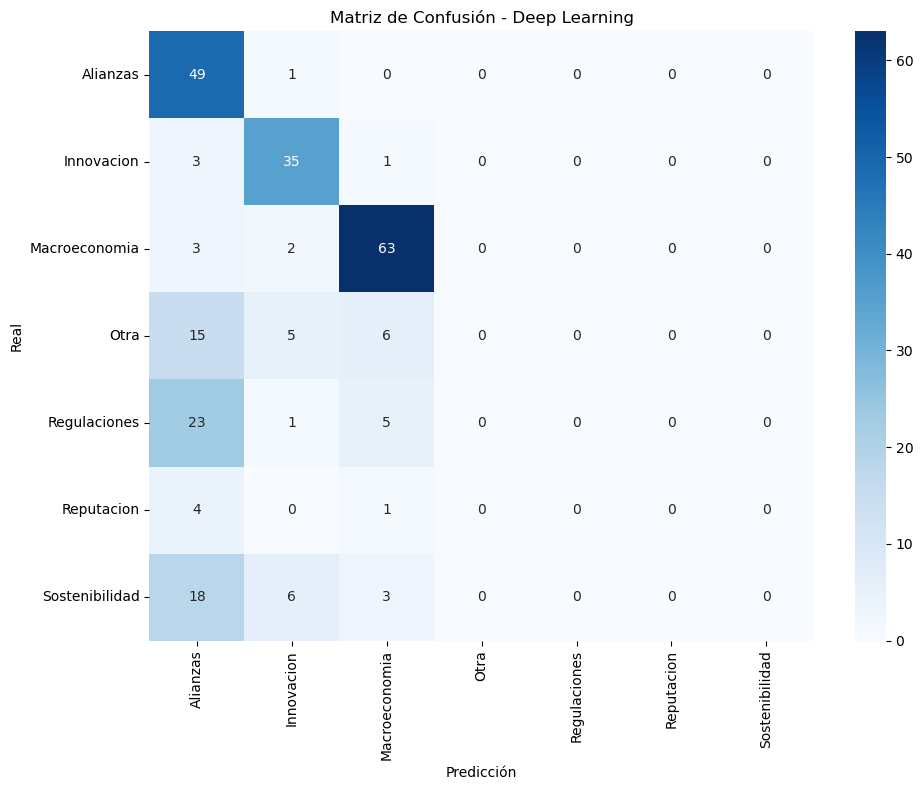

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluar
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)


print("RESULTADOS DEL MODELO DEEP LEARNING")

print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Predecir
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

# Reporte de clasificación
print(f"\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Matriz de Confusión - Deep Learning')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()

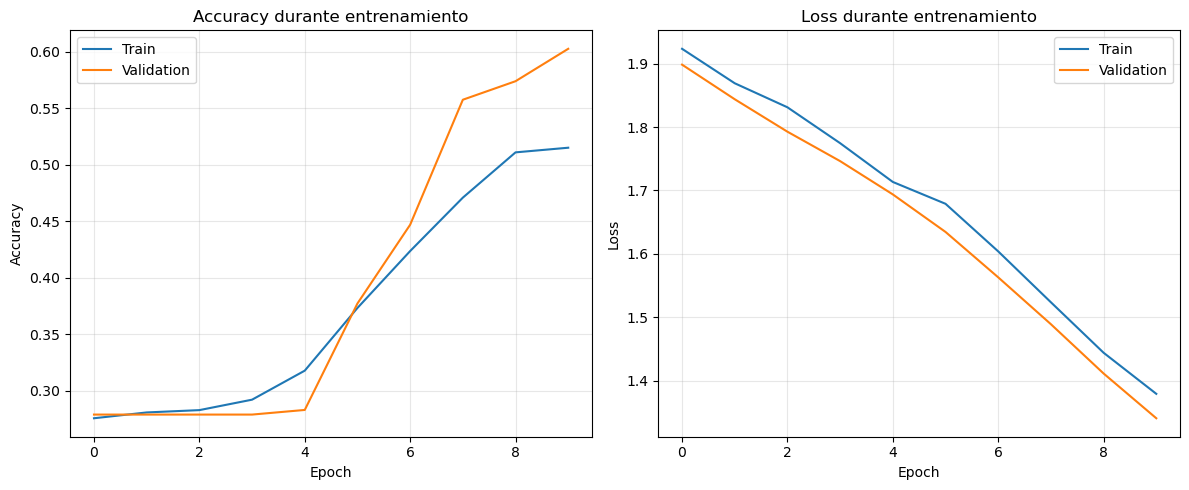

In [7]:
# Gráfico de precisión
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy durante entrenamiento')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss durante entrenamiento')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
def clasificar_noticia_dl(texto):
    """
    Clasifica una noticia nueva con el modelo de Deep Learning
    """
    # Tokenizar y hacer padding
    secuencia = tokenizer.texts_to_sequences([texto])
    padded_seq = pad_sequences(secuencia, maxlen=max_length)
    
    # Predecir
    prediccion_proba = model.predict(padded_seq, verbose=0)[0]
    clase_predicha_num = np.argmax(prediccion_proba)
    clase_predicha = le.inverse_transform([clase_predicha_num])[0]
    confianza = prediccion_proba[clase_predicha_num]
    
    return clase_predicha, confianza, prediccion_proba


# Probar
noticias_prueba = [
    "El equipo ganó el campeonato de fútbol en el estadio",
    "El presidente anunció nuevas medidas económicas",
    "La película ganó el premio Oscar a mejor director",
    "El gobierno aprobó la nueva ley de educación"
]

print("PRUEBA CON NOTICIAS NUEVAS (DEEP LEARNING)")

for noticia in noticias_prueba:
    categoria, confianza, probabilidades = clasificar_noticia_dl(noticia)
    
    print(f"\n📰 Noticia: {noticia}")
    print(f"   Categoría predicha: {categoria}")
    print(f"   Confianza: {confianza*100:.2f}%")
    
    # Mostrar probabilidades de todas las categorías
    print(f"   Probabilidades:")
    for i, clase in enumerate(le.classes_):
        print(f"      {clase}: {probabilidades[i]*100:.2f}%")

PRUEBA CON NOTICIAS NUEVAS (DEEP LEARNING)

📰 Noticia: El equipo ganó el campeonato de fútbol en el estadio
   Categoría predicha: Innovacion
   Confianza: 54.93%
   Probabilidades:
      Alianzas: 4.73%
      Innovacion: 54.93%
      Macroeconomia: 31.76%
      Otra: 2.72%
      Regulaciones: 2.31%
      Reputacion: 0.23%
      Sostenibilidad: 3.33%

📰 Noticia: El presidente anunció nuevas medidas económicas
   Categoría predicha: Innovacion
   Confianza: 56.40%
   Probabilidades:
      Alianzas: 4.51%
      Innovacion: 56.40%
      Macroeconomia: 30.76%
      Otra: 2.65%
      Regulaciones: 2.22%
      Reputacion: 0.22%
      Sostenibilidad: 3.25%

📰 Noticia: La película ganó el premio Oscar a mejor director
   Categoría predicha: Innovacion
   Confianza: 56.38%
   Probabilidades:
      Alianzas: 4.66%
      Innovacion: 56.38%
      Macroeconomia: 30.30%
      Otra: 2.74%
      Regulaciones: 2.32%
      Reputacion: 0.23%
      Sostenibilidad: 3.38%

📰 Noticia: El gobierno aprobó la n

In [ ]:
# Guardar modelo
model.save('modelo_clasificacion_noticias.keras')
print("Modelo guardado como 'modelo_clasificacion_noticias.keras'")

# Cargar modelo (para usar después)
# modelo_cargado = tf.keras.models.load_model('modelo_clasificacion_noticias.keras')

✅ Modelo guardado como 'modelo_clasificacion_noticias.keras'
